In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data=r"C:\Users\Lenovo\Documents\NareshIT\Data_files\Visadataset.csv"
visa_df=pd.read_csv(data)

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns


In [2]:
cat,num

(Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
        'requires_job_training', 'region_of_employment', 'unit_of_wage',
        'full_time_position', 'case_status'],
       dtype='object'),
 Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object'))

In [3]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [4]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- There are totatl 25480 applicants are there

- In that 25480 applicants 17018 applicants got the visa

- Also there are 16861 applicants are applied for visa from asia

- We want to know how many applicants form aisa got certified

- And how many applicants from asia got denied

In [5]:
visa_df['continent']
con1 = visa_df['continent']=='Asia'
visa_df['case_status']
con2 = visa_df['case_status']=='Certified'
con = con1 & con2
len(visa_df[con])

11012

In [6]:
# form different continents how many people are certified
values=visa_df['continent'].unique()
cert_count=[]
den_count=[]
for i in values:
    con1 = visa_df['continent']==i
    con2 = visa_df['case_status']=='Certified'
    con3 = visa_df['case_status']=='Denied'
    cert_con = con1 & con2
    den_con = con1 & con3
    cert_count.append(len(visa_df[cert_con]))
    den_count.append(len(visa_df[den_con]))
idx=values
pd.DataFrame(zip(cert_count,den_count),index=idx,columns=['Certified','Denied'])

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


In [7]:
labels=visa_df['continent'].unique()
cert_count,den_count=[],[]
for i in values:
    con1 = visa_df['continent']==i
    con2 = visa_df['case_status']=='Certified'
    con3 = visa_df['case_status']=='Denied'
    cert_con = con1 & con2
    den_con = con1 & con3
    cert_count.append(len(visa_df[cert_con]))
    den_count.append(len(visa_df[den_con]))
cols = sorted(visa_df['case_status'].unique())
pd.DataFrame(zip(cert_count,den_count),index=labels,columns=cols)

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


**cross tab**

In [8]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
pd.crosstab(col1,col2)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [9]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
pd.crosstab(col2,col1)

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


In [10]:
col1 = visa_df['continent']
col2 = visa_df['case_status']
r1=pd.crosstab(col1,col2)
r1

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

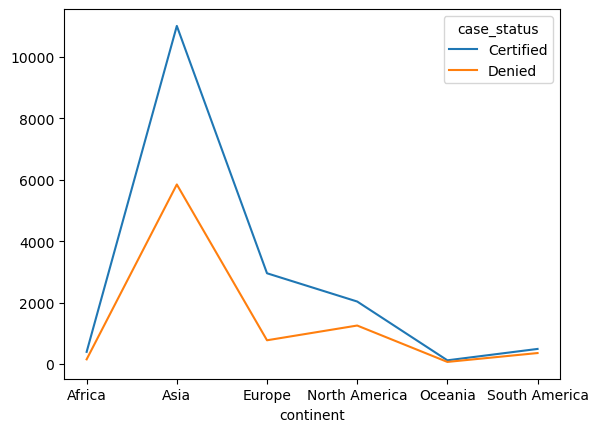

In [11]:
r1.plot()

<Axes: xlabel='continent'>

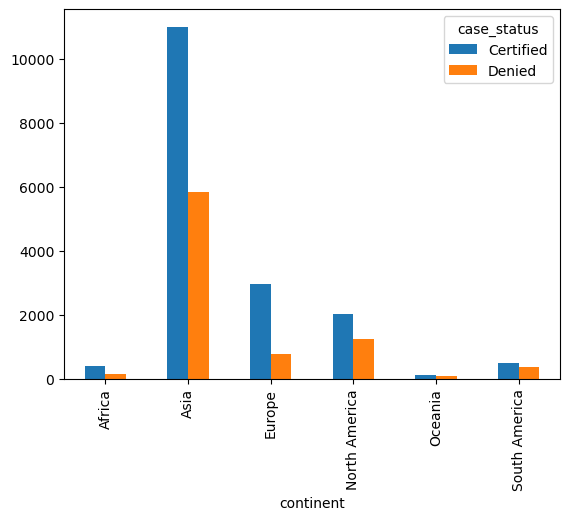

In [12]:
r1.plot(kind='bar')

**case status-continent-education_of_employee**

In [13]:
# from asia there 16k applicants applied for visa
# in that 11k+ ppl got certified
# in that 11k ppl different education applicants are avialable
# we want those information

In [14]:
# pd.crosstab()
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols = [col1,col2]
pd.crosstab(col3,cols)

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

In [15]:
# pd.crosstab()
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols = [col1,col2]
pd.crosstab(col3,cols).T

education_of_employee      Bachelor's  Doctorate  High School  Master's
continent     case_status                                              
Africa        Certified            81         43           23       250
              Denied               62         11           43        38
Asia          Certified          4407        780          676      5149
              Denied             2761        143         1614      1331
Europe        Certified          1040        788          162       967
              Denied              259         58          328       130
North America Certified           641        207          210       979
              Denied              584         51          191       429
Oceania       Certified            38         19           19        46
              Denied               28          3           17        22
South America Certified           160         75           74       184
              Denied              173         14           63       109

In [16]:
# pd.crosstab()
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols = [col2,col3]
pd.crosstab(col1,cols)

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [17]:
# pd.crosstab()
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols = [col1,col3]
pd.crosstab(col2,cols).T

case_status                          Certified  Denied
continent     education_of_employee                   
Africa        Bachelor's                    81      62
              Doctorate                     43      11
              High School                   23      43
              Master's                     250      38
Asia          Bachelor's                  4407    2761
              Doctorate                    780     143
              High School                  676    1614
              Master's                    5149    1331
Europe        Bachelor's                  1040     259
              Doctorate                    788      58
              High School                  162     328
              Master's                     967     130
North America Bachelor's                   641     584
              Doctorate                    207      51
              High School                  210     191
              Master's                     979     429
Oceania       Bachelor's                    38      28
              Doctorate                     19       3
              High School                   19      17
              Master's                      46      22
South America Bachelor's                   160     173
              Doctorate                     75      14
              High School                   74      63
              Master's                     184     109

In [18]:
# pd.crosstab()
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols = [col1,col3]
pd.crosstab(col2,cols)

continent                 Africa                                      Asia  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
case_status                                                                  
Certified                     81        43          23      250       4407   
Denied                        62        11          43       38       2761   

continent                                                Europe            \
education_of_employee Doctorate High School Master's Bachelor's Doctorate   
case_status                                                                 
Certified                   780         676     5149       1040       788   
Denied                      143        1614     1331        259        58   

continent              ... North America             Oceania            \
education_of_employee  ...   High School Master's Bachelor's Doctorate   
case_status            ...                                               
Certified              ...           210      979         38        19   
Denied                 ...           191      429         28         3   

continent                                  South America            \
education_of_employee High School Master's    Bachelor's Doctorate   
case_status                                                          
Certified                      19       46           160        75   
Denied                         17       22           173        14   

continent                                   
education_of_employee High School Master's  
case_status                                 
Certified                      74      184  
Denied                         63      109  

[2 rows x 24 columns]

In [19]:
# pd.crosstab()
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols = [col2,col3]
r2=pd.crosstab(col1,cols)

<Axes: xlabel='continent'>

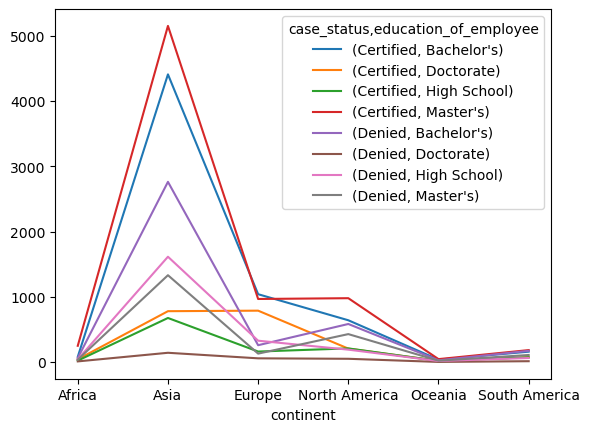

In [20]:
r2.plot()

**group by**

In [21]:
visa_df['education_of_employee'].value_counts()

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

In [22]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [23]:
print(list(visa_df.groupby('education_of_employee')))

[("Bachelor's",          case_id      continent education_of_employee has_job_experience  \
2         EZYV03           Asia            Bachelor's                  N   
3         EZYV04           Asia            Bachelor's                  N   
6         EZYV07           Asia            Bachelor's                  N   
7         EZYV08  North America            Bachelor's                  Y   
8         EZYV09           Asia            Bachelor's                  N   
...          ...            ...                   ...                ...   
25466  EZYV25467         Europe            Bachelor's                  Y   
25468  EZYV25469           Asia            Bachelor's                  N   
25473  EZYV25474           Asia            Bachelor's                  Y   
25475  EZYV25476           Asia            Bachelor's                  Y   
25479  EZYV25480           Asia            Bachelor's                  Y   

      requires_job_training  no_of_employees  yr_of_estab  \
2         

In [24]:
visa_df.groupby('education_of_employee').count()

,case_id,continent,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
education_of_employee,,,,,,,,,,,
Bachelor's,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234
Doctorate,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192
High School,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420
Master's,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634


In [25]:
visa_df.groupby('education_of_employee').size()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
dtype: int64

In [26]:
# based on group by select an another column
visa_df.groupby('education_of_employee')['prevailing_wage']

In [27]:
visa_df['prevailing_wage'].mean()
# mean wage of all 24580 observation
# Bachelors,Dostor,Highschool,master

np.float64(74455.81459209183)

In [28]:
visa_df[visa_df['education_of_employee']=="Bachelor's"]['prevailing_wage'].mean()

np.float64(73405.44373547)

In [29]:
visa_df.groupby('education_of_employee')['prevailing_wage'].mean()

education_of_employee
Bachelor's     73405.443735
Doctorate      64561.076657
High School    71582.147756
Master's       78843.057843
Name: prevailing_wage, dtype: float64

In [30]:
con = visa_df['case_status'] == 'Certified'
new_df = visa_df[con]
new_df.groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [31]:
con = visa_df['case_status'] == 'Denied'
new_df = visa_df[con]
new_df.groupby('continent').size()

continent
Africa            154
Asia             5849
Europe            775
North America    1255
Oceania            70
South America     359
dtype: int64

In [32]:
visa_df['prevailing_wage'].min()
con=visa_df['continent'] == 'Asia'
new_df = visa_df[con]
new_df['prevailing_wage'].min()

3.3188

In [33]:
visa_df.groupby('continent')['prevailing_wage'].min()

continent
Africa           32.9286
Asia              3.3188
Europe            9.1753
North America     2.1367
Oceania          24.4888
South America     3.0031
Name: prevailing_wage, dtype: float64

- we have seen continent and case status

- we have seen three variable continent, case status and Education of employee

- we also done similar analysis using group by

- Only categorical column analysis completed

- Only numerical column analysis completed

- Also Bi variate and multivariate analysis also completed

- Now we need to perform Two numerical column analysis

    - This will give relation between two columns which are numerical in nature

    - So we can perform correlation matrix to get the relationship

    - also we need to perform scatter plots to visualize the relation

**scatter plots**

**plt.scatter**

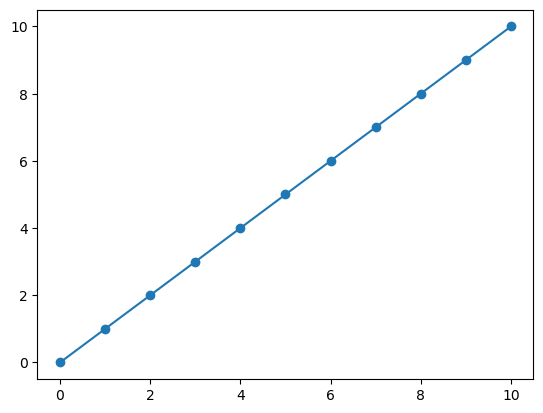

In [35]:
x = range(0,11)
y = range(0,11)
plt.scatter(x,y)
plt.plot(x,y)

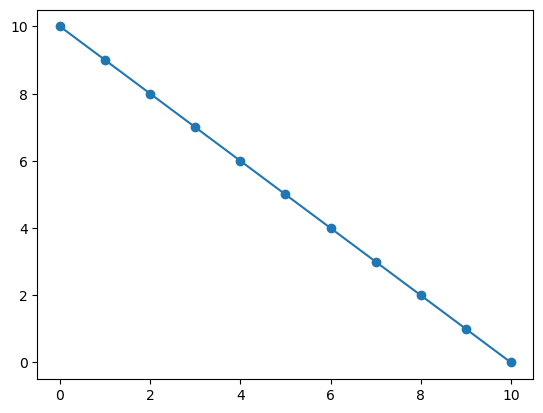

In [37]:
x = range(0,11)
y = range(10,-1,-1)
plt.scatter(x,y)
plt.plot(x,y)

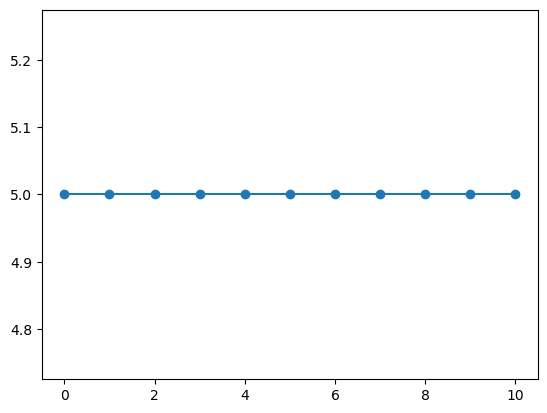

In [38]:
x = range(0,11)
y = [5 for i in range(0,11)]
plt.scatter(x,y)
plt.plot(x,y)

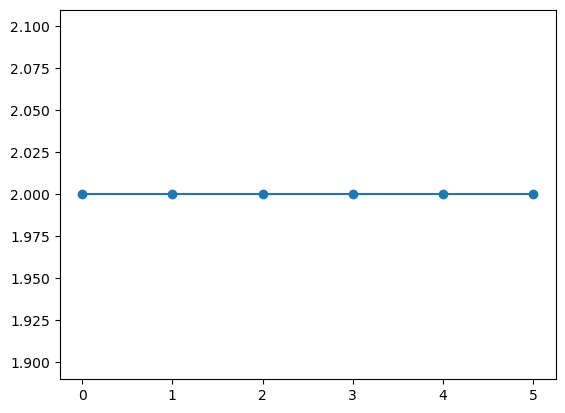

In [42]:
x = range(0,6)
y = [2 for i in range(0,6)]
plt.scatter(x,y)
plt.plot(x,y)

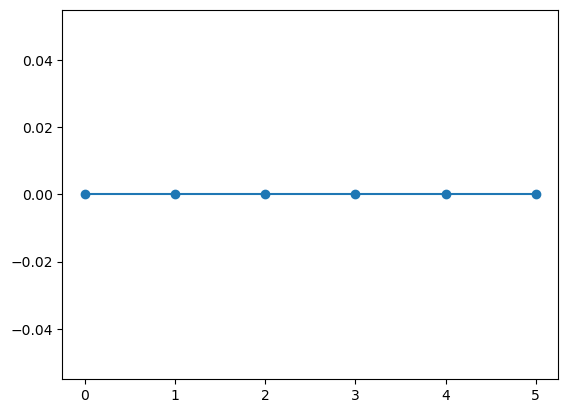

In [43]:
x = range(0,6)
y = [0 for i in range(0,6)]
plt.scatter(x,y)
plt.plot(x,y)

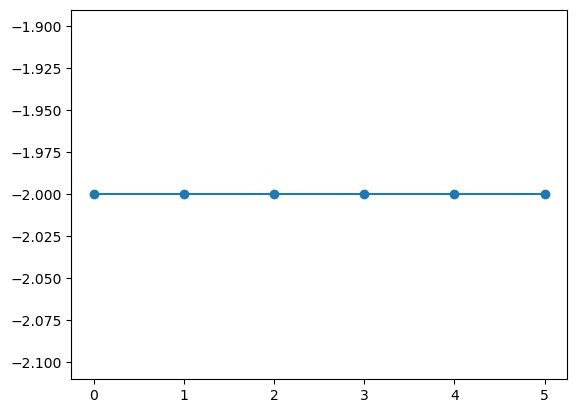

In [44]:
x = range(0,6)
y = [-2 for i in range(0,6)]
plt.scatter(x,y)
plt.plot(x,y)

In [45]:
cat,num

(Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
        'requires_job_training', 'region_of_employment', 'unit_of_wage',
        'full_time_position', 'case_status'],
       dtype='object'),
 Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object'))

In [82]:
visa_corr=visa_df.corr(numeric_only=True)

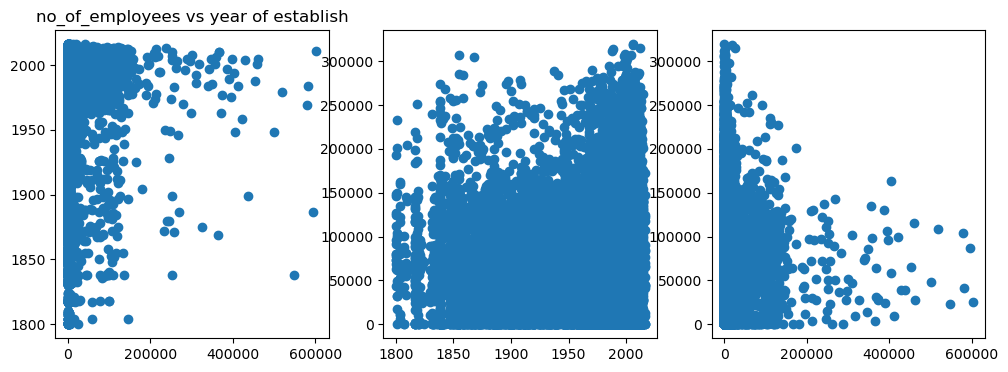

In [66]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(12,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.title('no_of_employees vs year of establish')
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

In [13]:
data = r"C:\Users\Lenovo\Documents\NareshIT\Data_files\winequality_red.csv"
wine_df = pd.read_csv(data)
wine_df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [7]:
cat = wine_df.select_dtypes(include='object')
num = wine_df.select_dtypes(exclude='object')
num.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [8]:
wine_corr=wine_df.corr()

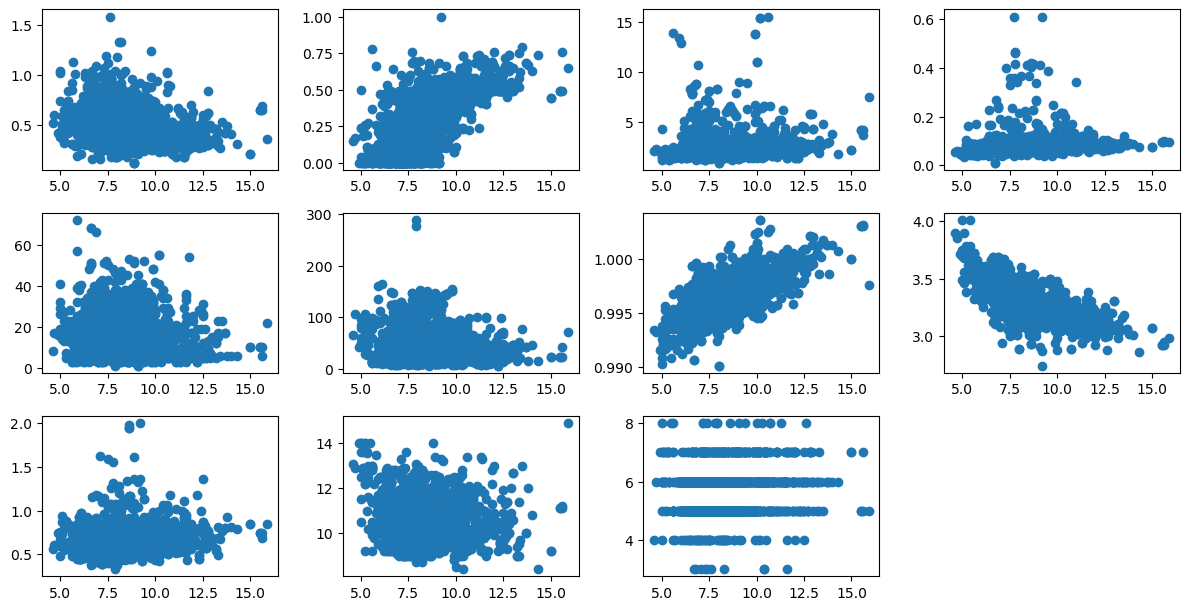

In [9]:
col1=wine_df['fixed acidity']
col2=wine_df['volatile acidity']
col3=wine_df['citric acid'] 
col4=wine_df['residual sugar']
col5=wine_df['chlorides']
col6=wine_df['free sulfur dioxide']
col7=wine_df['total sulfur dioxide']
col8=wine_df['density']
col9=wine_df['pH']
col10=wine_df['sulphates']
col11=wine_df['alcohol']
col12=wine_df['quality']
plt.figure(figsize=(12, 8))

plt.subplot(4, 4, 1);  plt.scatter(col1, col2)
plt.subplot(4, 4, 2);  plt.scatter(col1, col3)
plt.subplot(4, 4, 3);  plt.scatter(col1, col4)
plt.subplot(4, 4, 4);  plt.scatter(col1, col5)

plt.subplot(4, 4, 5);  plt.scatter(col1, col6)
plt.subplot(4, 4, 6);  plt.scatter(col1, col7)
plt.subplot(4, 4, 7);  plt.scatter(col1, col8)
plt.subplot(4, 4, 8);  plt.scatter(col1, col9)

plt.subplot(4, 4, 9);  plt.scatter(col1, col10)
plt.subplot(4, 4,10);  plt.scatter(col1, col11)
plt.subplot(4, 4,11);  plt.scatter(col1, col12)

plt.tight_layout()
plt.show()


**Heat map**

- Any matrix values we can visualize using a heat map

- Heat map will provide colors for different values

- Heat map also provides colors bar which indicates, the color and its value

- For example the values ranges from 0.8 to display 1 display as **blue color**

- So we no need to check values, we can directly see the blue color

- So immediately we can sence blue color means highest values which means is 0.8 to 1

- Heat map avialble in **seaborn**

<Axes: >

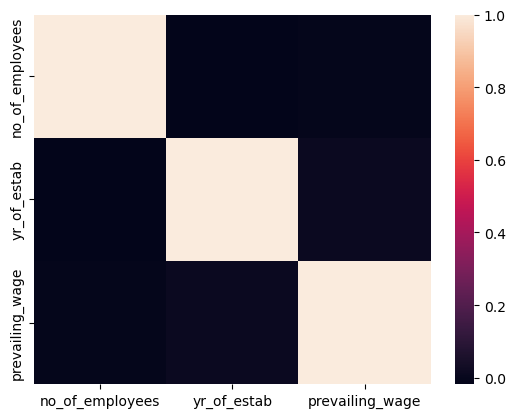

In [10]:
visa_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr)

<Axes: >

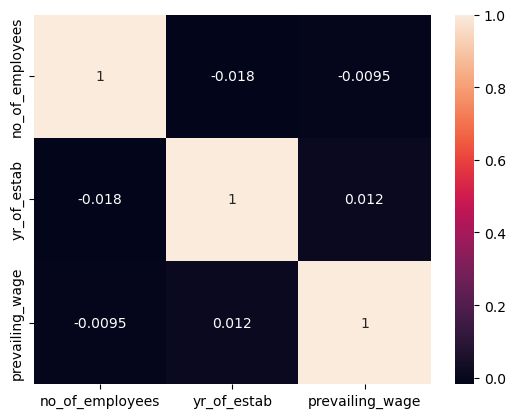

In [88]:
visa_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr,annot=True)

<Axes: >

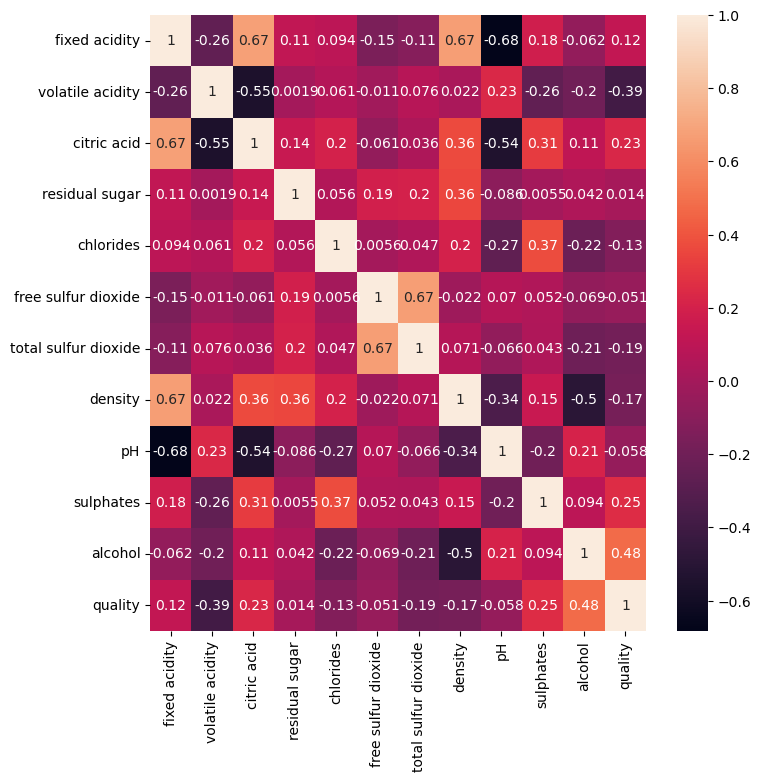

In [90]:
wine_corr=wine_df.corr()
plt.figure(figsize=(8,8))
sns.heatmap(wine_corr,annot=True)

In [94]:
wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

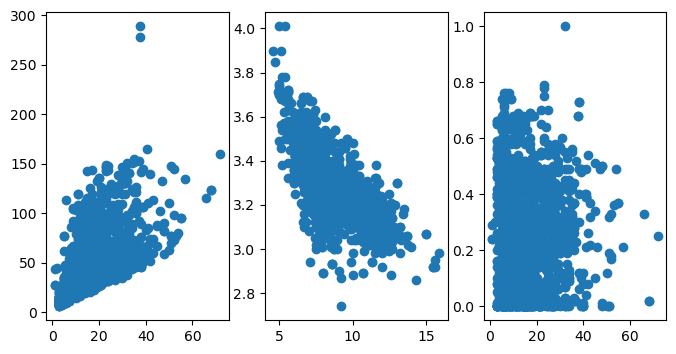

In [12]:
col1=wine_df['free sulfur dioxide']
col2=wine_df['total sulfur dioxide']
col3=wine_df['fixed acidity']
col4=wine_df['pH']
col5=wine_df['citric acid']
plt.figure(figsize=(8,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col3,col4)
plt.subplot(1,3,3).scatter(col1,col5)

